# All nine eclipses, aligned at expected mid-eclipse

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml

# The notebook lives in Rocky-Worlds/notebooks and the importable `pipeline`
# package lives one directory above it. This also works when launched from
# the Rocky-Worlds repository root.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, *cwd.parents]
REPO_ROOT = next((p for p in candidates if (p / "pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate the Rocky-Worlds repository. Start Jupyter from "
        "Rocky-Worlds or Rocky-Worlds/notebooks."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pipeline.utils.io import load_photometry_dataset, preprocess_dataset
from pipeline.utils.models import detec_model, detec_parameter_count

print(f"Repository: {REPO_ROOT}")


Repository: /home/ssalhi/Rocky-Worlds


## Inputs

Replace every placeholder below. `fit_dir` is the generated `individual_fit_...` folder. `data_path` may be the `SpecData.h5` file itself or a directory containing it. Times must use the same MJD system as the HDF5 `time` array.

`period_days` is needed to convert elapsed time to orbital phase. A shared value can be set with `DEFAULT_PERIOD_DAYS`; an entry-specific value overrides it.

In [11]:
DEFAULT_PERIOD_DAYS = 24.7372457

ECLIPSES = [
    {"label": "Eclipse 1", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse1/individual_fit_exp_linear_20260805_144301", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse1/stage3/S3_2026-06-12_miri_lhs1140_eclipse1_run3/ap5_bg12_30/S3_miri_lhs1140_eclipse1_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61231.804273},
    {"label": "Eclipse 2", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse2/individual_fit_exp_linear_20260805_144833", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse2/stage3/S3_2026-06-12_miri_lhs1140_eclipse2_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse2_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61256.541079},
    {"label": "Eclipse 3", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse3/individual_fit_exp_20260805_111109", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse3/stage3/S3_2026-06-12_miri_lhs1140_eclipse3_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse3_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61355.488301},
    {"label": "Eclipse 4", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse4/individual_fit_exp_linear_20260728_121253", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse4/stage3/S3_2026-06-12_miri_lhs1140_eclipse4_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse4_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61380.225801},
    {"label": "Eclipse 5", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse5/individual_fit_exp_polynomial_20260728_161242", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse5/stage3/S3_2026-06-13_miri_lhs1140_eclipse5_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse5_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61404.962606},
    {"label": "Eclipse 6", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse6/individual_fit_exp_linear_20260729_113902", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse6/stage3/S3_2026-06-15_miri_lhs1140_eclipse6_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse6_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61578.120940},
    {"label": "Eclipse 7", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse7/individual_fit_exp_20260729_114327", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse7/stage3/S3_2026-06-14_miri_lhs1140_eclipse7_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse7_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61602.857745},
    {"label": "Eclipse 8", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse8/individual_fit_exp_20260729_115622", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse8/stage3/S3_2026-06-14_miri_lhs1140_eclipse8_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse8_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61627.594551},
    {"label": "Eclipse 9", "fit_dir": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step2/eclipse9/individual_fit_exp_20260805_162344", "data_path": "/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse9/stage3/S3_2026-06-14_miri_lhs1140_eclipse9_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse9_ap5_bg12_30_SpecData.h5", "expected_midtime_mjd": 61726.542467},
]

CORRECTION_MODE = "divide"  # "divide" (recommended) or "subtract"
BIN_DATA = True
N_BINS = 150
PHASE_LIMITS = (0.48, 0.54)
VERTICAL_OFFSET = 0.005  # e.g. 0.0015 to stack the nine light curves
OUTPUT_PATH = REPO_ROOT / "all_9_eclipses_phase_aligned_bin150_archivetimes.png"

## Loading and correction helpers

The saved maximum-likelihood vector is loaded from `best_params.npy` when present, or from `summary.json['best']` as a fallback. `final_state.npy` contains the final ensemble of walkers rather than a single best-fit vector, so it is used only as a last-resort fallback (the median walker). The detrending coefficients are selected by their `c_...` labels, avoiding assumptions about their position beyond the fit's own saved metadata.

In [4]:
def load_yaml(path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return yaml.safe_load(handle)


def load_fit_products(fit_dir):
    fit_dir = Path(fit_dir).expanduser()
    config_path = fit_dir / "config_resolved.yaml"
    if not config_path.exists():
        config_path = fit_dir / "config_input.yaml"
    if not config_path.exists():
        raise FileNotFoundError(f"No config_resolved.yaml or config_input.yaml in {fit_dir}")

    summary_path = fit_dir / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary.json in {fit_dir}")
    with summary_path.open("r", encoding="utf-8") as handle:
        summary = json.load(handle)

    best_path = fit_dir / "best_params.npy"
    final_state_path = fit_dir / "final_state.npy"
    if best_path.exists():
        best = np.asarray(np.load(best_path), dtype=float).squeeze()
        parameter_source = "best_params.npy"
    elif "best" in summary:
        best = np.asarray(summary["best"], dtype=float).squeeze()
        parameter_source = "summary.json['best']"
    elif final_state_path.exists():
        state = np.asarray(np.load(final_state_path), dtype=float)
        best = np.nanmedian(state, axis=0) if state.ndim == 2 else state.squeeze()
        parameter_source = "median(final_state.npy)"
    else:
        raise FileNotFoundError(f"No fitted parameter vector found in {fit_dir}")

    if best.ndim != 1:
        raise ValueError(f"Expected a one-dimensional parameter vector in {fit_dir}; got {best.shape}")
    return load_yaml(config_path), summary, best, parameter_source


def extract_detrending_parameters(summary, best, model_type):
    labels = list(summary.get("labels", []))
    n_detec = detec_parameter_count(model_type)
    coefficient_indices = [i for i, label in enumerate(labels) if str(label).startswith("c_")]
    if len(coefficient_indices) == n_detec:
        return best[coefficient_indices]
    # Individual fits are ordered [dt_s, fp, c_1, ..., c_n, sigF].
    if best.size == n_detec + 3:
        return best[2:-1]
    raise ValueError(
        f"Could not identify {n_detec} detrending parameters for model '{model_type}'. "
        f"Saved labels={labels}, parameter-vector length={best.size}."
    )


def bin_series(x, y, yerr, n_bins, limits):
    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
    finite &= (x >= limits[0]) & (x <= limits[1])
    x, y, yerr = x[finite], y[finite], yerr[finite]
    edges = np.linspace(limits[0], limits[1], n_bins + 1)
    index = np.digitize(x, edges) - 1
    xb, yb, eb = [], [], []
    for i in range(n_bins):
        use = index == i
        if not np.any(use):
            continue
        xb.append(np.nanmedian(x[use]))
        yb.append(np.nanmedian(y[use]))
        # Propagate the input uncertainties for the unweighted bin mean.
        eb.append(np.sqrt(np.nansum(yerr[use] ** 2)) / np.sum(use))
    return np.asarray(xb), np.asarray(yb), np.asarray(eb)


def prepare_eclipse(entry):
    expected_midtime = float(entry["expected_midtime_mjd"])
    if not np.isfinite(expected_midtime):
        raise ValueError(f"Enter a finite expected_midtime_mjd for {entry['label']}")
    period_days = float(entry.get("period_days", DEFAULT_PERIOD_DAYS))
    if not np.isfinite(period_days) or period_days <= 0:
        raise ValueError(f"period_days must be positive for {entry['label']}")

    config, summary, best, parameter_source = load_fit_products(entry["fit_dir"])
    raw = load_photometry_dataset(entry["data_path"])
    preprocessing = config.get("preprocessing", {})
    data = preprocess_dataset(
        raw,
        normalize=preprocessing.get("normalize", "median"),
        sigma_clip=preprocessing.get("sigma_clip", 4.0),
    )

    model_type = config["detrending"]["model_type"]
    coefficients = extract_detrending_parameters(summary, best, model_type)
    trend = detec_model(
        data["time_hours"], data["centroid_x"], data["centroid_y"], coefficients, model_type
    )
    valid_trend = np.isfinite(trend) & (trend != 0)
    if CORRECTION_MODE == "divide":
        corrected = np.divide(data["flux"], trend, out=np.full_like(data["flux"], np.nan), where=valid_trend)
        corrected_err = np.divide(data["flux_err"], np.abs(trend), out=np.full_like(data["flux_err"], np.nan), where=valid_trend)
    elif CORRECTION_MODE == "subtract":
        corrected = data["flux"] - trend + 1.0
        corrected_err = data["flux_err"].copy()
    else:
        raise ValueError("CORRECTION_MODE must be 'divide' or 'subtract'.")

    # By construction, time_mjd == expected_midtime gives phase == 0.5.
    phase = 0.5 + (data["time_mjd"] - expected_midtime) / period_days
    return {
        "label": entry["label"], "phase": phase, "flux": corrected,
        "flux_err": corrected_err, "trend": trend, "model_type": model_type,
        "parameter_source": parameter_source, "n_points": data["n_points"],
    }

## Load all nine eclipses

This cell validates the list length, processes every eclipse, and prints which detrending model and saved parameter product were used.

In [5]:
if len(ECLIPSES) != 9:
    raise ValueError(f"Expected exactly 9 eclipse entries, received {len(ECLIPSES)}.")

processed = [prepare_eclipse(entry) for entry in ECLIPSES]
for item in processed:
    print(f"{item['label']}: {item['n_points']} points | {item['model_type']} | {item['parameter_source']}")

Eclipse 1: 4618 points | exp+linear | best_params.npy
Eclipse 2: 2271 points | exp+linear | best_params.npy
Eclipse 3: 2283 points | exp | best_params.npy
Eclipse 4: 3348 points | exp+linear | best_params.npy
Eclipse 5: 2283 points | exp+polynomial | best_params.npy
Eclipse 6: 3297 points | exp+linear | best_params.npy
Eclipse 7: 2440 points | exp | best_params.npy
Eclipse 8: 3930 points | exp | best_params.npy
Eclipse 9: 2457 points | exp | best_params.npy


## Master plot

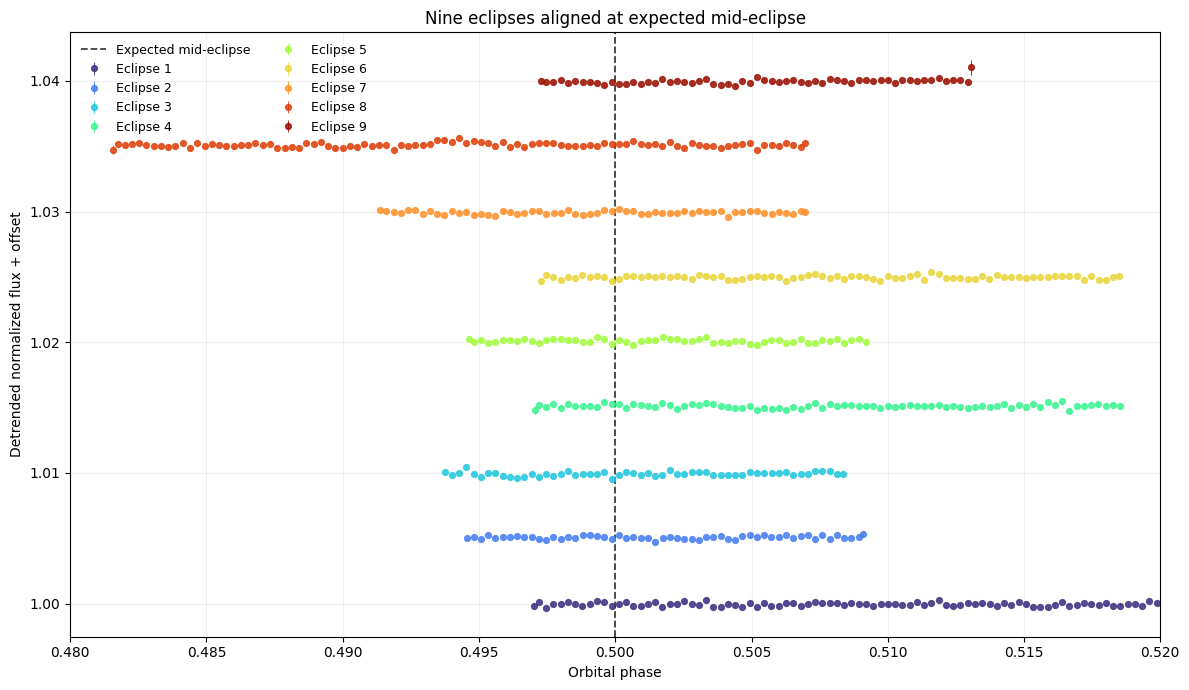

Saved: /home/ssalhi/Rocky-Worlds/all_9_eclipses_phase_aligned_bin150_archivetimes.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.colormaps["turbo"](np.linspace(0.04, 0.96, len(processed)))

for i, (item, color) in enumerate(zip(processed, colors)):
    phase, flux, flux_err = item["phase"], item["flux"], item["flux_err"]
    if BIN_DATA:
        phase, flux, flux_err = bin_series(phase, flux, flux_err, N_BINS, PHASE_LIMITS)
    offset = i * VERTICAL_OFFSET
    ax.errorbar(
        phase, flux + offset, yerr=flux_err, fmt="o", ms=4.2 if BIN_DATA else 2.0,
        elinewidth=0.8, capsize=0, alpha=0.82, color=color, label=item["label"], rasterized=True,
    )

ax.axvline(0.5, color="black", ls="--", lw=1.3, alpha=0.75, label="Expected mid-eclipse")
ax.set_xlim(*PHASE_LIMITS)
ax.set_xlabel("Orbital phase")
ylabel = "Detrended normalized flux" + (" + offset" if VERTICAL_OFFSET else "")
ax.set_ylabel(ylabel)
ax.set_title("Nine eclipses aligned at expected mid-eclipse")
ax.grid(alpha=0.18)
ax.legend(ncols=2, fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_PATH, dpi=250, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_PATH}")

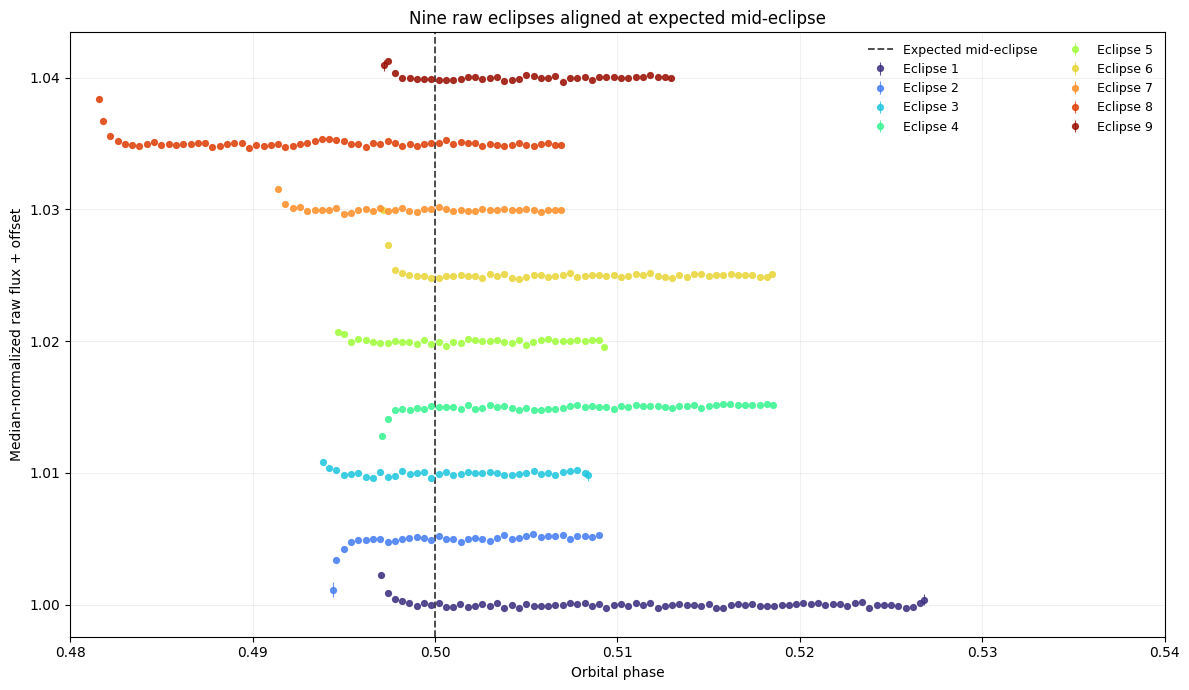

Saved raw-data plot: /home/ssalhi/Rocky-Worlds/all_9_eclipses_phase_aligned_bin150_archivetimes_raw.png


In [12]:
# Raw-data version of the master plot: direct time, aplev, and aperr values
# from each HDF5 file. Each eclipse is median-normalized to a baseline of 1,
# but no sigma clipping, detrending, or fitted model is applied.
raw_processed = []
for entry in ECLIPSES:
    expected_midtime = float(entry["expected_midtime_mjd"])
    if not np.isfinite(expected_midtime):
        raise ValueError(f"Enter a finite expected_midtime_mjd for {entry['label']}")
    period_days = float(entry.get("period_days", DEFAULT_PERIOD_DAYS))
    if not np.isfinite(period_days) or period_days <= 0:
        raise ValueError(f"period_days must be positive for {entry['label']}")

    raw = load_photometry_dataset(entry["data_path"])
    time_raw = np.asarray(raw["time"], dtype=float)
    flux_raw = np.asarray(raw["flux"], dtype=float)
    flux_err_raw = np.asarray(raw["flux_err"], dtype=float)
    if not (time_raw.shape == flux_raw.shape == flux_err_raw.shape):
        raise ValueError(
            f"Raw time/aplev/aperr shapes do not match for {entry['label']}: "
            f"{time_raw.shape}, {flux_raw.shape}, {flux_err_raw.shape}"
        )
    finite_flux = np.isfinite(flux_raw)
    baseline = float(np.nanmedian(flux_raw[finite_flux])) if np.any(finite_flux) else np.nan
    if not np.isfinite(baseline) or baseline == 0.0:
        raise ValueError(f"Cannot determine a finite, non-zero raw-flux baseline for {entry['label']}")
    flux_raw_normalized = flux_raw / baseline
    flux_err_raw_normalized = flux_err_raw / abs(baseline)

    phase_raw = 0.5 + (time_raw - expected_midtime) / period_days
    raw_processed.append({
        "label": entry["label"], "phase": phase_raw,
        "flux": flux_raw_normalized, "flux_err": flux_err_raw_normalized,
        "baseline": baseline,
    })

fig, ax = plt.subplots(figsize=(12, 7))
raw_colors = plt.colormaps["turbo"](np.linspace(0.04, 0.96, len(raw_processed)))
for i, (item, color) in enumerate(zip(raw_processed, raw_colors)):
    phase, flux, flux_err = item["phase"], item["flux"], item["flux_err"]
    if BIN_DATA:
        phase, flux, flux_err = bin_series(phase, flux, flux_err, N_BINS, PHASE_LIMITS)
    offset = i * VERTICAL_OFFSET
    ax.errorbar(
        phase, flux + offset, yerr=flux_err, fmt="o", ms=4.2 if BIN_DATA else 2.0,
        elinewidth=0.8, capsize=0, alpha=0.82, color=color,
        label=item["label"], rasterized=True,
    )

ax.axvline(0.5, color="black", ls="--", lw=1.3, alpha=0.75, label="Expected mid-eclipse")
ax.set_xlim(*PHASE_LIMITS)
ax.set_xlabel("Orbital phase")
raw_ylabel = "Median-normalized raw flux" + (" + offset" if VERTICAL_OFFSET else "")
ax.set_ylabel(raw_ylabel)
ax.set_title("Nine raw eclipses aligned at expected mid-eclipse")
ax.grid(alpha=0.18)
ax.legend(ncols=2, fontsize=9, frameon=False)
fig.tight_layout()
RAW_OUTPUT_PATH = OUTPUT_PATH.with_name(f"{OUTPUT_PATH.stem}_raw{OUTPUT_PATH.suffix}")
fig.savefig(RAW_OUTPUT_PATH, dpi=250, bbox_inches="tight")
plt.show()
print(f"Saved raw-data plot: {RAW_OUTPUT_PATH}")